In [1]:
import os
import json
import kagglehub
import numpy as np
import pandas as pd
import math

#Procesamiento de Texto y Configuración
from textblob import TextBlob
from sklearn import set_config
set_config(display='diagram') 

# Visualización de Datos
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Preprocesamiento y Pipelines
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler

# Modelos de Regresión (Continuo)
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet, 
    Lars, BayesianRidge, SGDRegressor
)

# Modelos de Clasificación (Discreto)
from sklearn.linear_model import LogisticRegression

#Métricas de Evaluación
# Para Regresión
from sklearn.metrics import (
    r2_score, mean_absolute_error, 
    mean_absolute_percentage_error, mean_squared_error,
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix, 
    classification_report, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# Para Clasificación
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
# Enviroment setup
set_config(display="diagram")
pd.set_option("display.max_columns", 50)
pd.set_option('display.float_format', lambda x: '%.8f' % x)

/home/jimmii/Documentos/DiplomadoCienciaDeDatos2025-2026/RepoJime/-Titulacion-DiplomadoCienciaDeDatos/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Download latest version
path = kagglehub.dataset_download("datasnaek/youtube")

print("Path to dataset files:", path)

Path to dataset files: /home/jimmii/.cache/kagglehub/datasets/datasnaek/youtube/versions/24


In [3]:
# Listar los archivos para saber el nombre exacto
archivos = os.listdir(path)
print("Archivos disponibles:", archivos)

Archivos disponibles: ['US_category_id.json', 'USvideos.csv', 'GBvideos.csv', 'GB_category_id.json', 'GBcomments.csv', 'UScomments.csv']


In [4]:
csv_path_GBvideos= os.path.join(path, 'GBvideos.csv')
df_GBvideos = pd.read_csv(csv_path_GBvideos, on_bad_lines='skip')
csv_path_GBcomments= os.path.join(path, 'GBcomments.csv')
df_GBcomments = pd.read_csv(csv_path_GBcomments, on_bad_lines='skip')

In [5]:
df_GBvideos.head(5)

,video_id,title,channel_title,category_id,tags,views,likes,dislikes,comment_total,thumbnail_link,date
0,jt2OHQh0HoQ,Live Apple Event - Apple September Event 2017 ...,Apple Event,28,apple events|apple event|iphone 8|iphone x|iph...,7426393,78240,13548,705,https://i.ytimg.com/vi/jt2OHQh0HoQ/default_liv...,13.09000000
1,AqokkXoa7uE,Holly and Phillip Meet Samantha the Sex Robot ...,This Morning,24,this morning|interview|holly willoughby|philli...,494203,2651,1309,0,https://i.ytimg.com/vi/AqokkXoa7uE/default.jpg,13.09000000
2,YPVcg45W0z4,My DNA Test Results! I'm WHAT?!,emmablackery,24,emmablackery|emma blackery|emma|blackery|briti...,142819,13119,151,1141,https://i.ytimg.com/vi/YPVcg45W0z4/default.jpg,13.09000000
3,T_PuZBdT2iM,getting into a conversation in a language you ...,ProZD,1,skit|korean|language|conversation|esl|japanese...,1580028,65729,1529,3598,https://i.ytimg.com/vi/T_PuZBdT2iM/default.jpg,13.09000000
4,NsjsmgmbCfc,Baby Name Challenge!,Sprinkleofglitter,26,sprinkleofglitter|sprinkle of glitter|baby gli...,40592,5019,57,490,https://i.ytimg.com/vi/NsjsmgmbCfc/default.jpg,13.09000000


In [6]:
df_GBvideos.describe()

,category_id,views,likes,dislikes,comment_total,date
count,7993.00000000,7993.00000000,7993.00000000,7993.00000000,7993.00000000,7993.00000000
mean,19.73827099,1110732.58864006,38859.66282998,1528.85887652,4991.63117728,16.08887401
std,7.17813231,3048739.98641341,109295.07652466,8176.70778757,26837.13551816,7.67817577
min,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,1.10000000
25%,17.00000000,108375.00000000,2580.00000000,71.00000000,308.00000000,10.10000000
50%,23.00000000,315194.00000000,9561.00000000,249.00000000,1038.00000000,16.10000000
75%,24.00000000,971221.00000000,31593.00000000,867.00000000,3327.00000000,21.10000000
max,29.00000000,58961407.00000000,2289911.00000000,192725.00000000,813322.00000000,30.09000000


In [7]:
df_GBcomments.rename(columns={'likes': 'likes_comment'}, inplace=True)
df_GBcomments.rename(columns={'replies': 'replies_comment'}, inplace=True)

In [8]:
df_GBcomments.head(5)

,video_id,comment_text,likes_comment,replies_comment
0,jt2OHQh0HoQ,It's more accurate to call it the M+ (1000) be...,0,0
1,jt2OHQh0HoQ,To be there with a samsung phone\n😂😂😂,1,0
2,jt2OHQh0HoQ,"Thank gosh, a place I can watch it without hav...",0,0
3,jt2OHQh0HoQ,What happened to the home button on the iPhone...,0,0
4,jt2OHQh0HoQ,Power is the disease. Care is the cure. Keep...,0,0


In [9]:
df_GBcomments.describe()

,likes_comment,replies_comment
count,718452.00000000,718452.00000000
mean,5.23745358,0.38125024
std,203.88389330,8.96795831
min,0.00000000,0.00000000
25%,0.00000000,0.00000000
50%,0.00000000,0.00000000
75%,0.00000000,0.00000000
max,60630.00000000,521.00000000


In [10]:
df_GBcomments.shape

(718452, 4)

In [11]:
csv_path_GB_category_id = os.path.join(path, 'GB_category_id.json')
with open(csv_path_GB_category_id, 'r') as f:
    data = json.load(f)

categories = []
for category in data['items']:
    categories.append({
        'category_id': int(category['id']),
        'name': category['snippet']['title']
    })

df_GB_category_id = pd.DataFrame(categories)
df_GB_category_id.head(5)

,category_id,name
0,1,Film & Animation
1,2,Autos & Vehicles
2,10,Music
3,15,Pets & Animals
4,17,Sports


In [12]:
df_GBvideos.shape

(7993, 11)

In [13]:
# Unir Videos con Categorías (usando el ID)
# Esto añade la columna 'category_name' a videos
df_videos_con_cat = pd.merge(df_GBvideos, df_GB_category_id, on='category_id', how='left')

In [14]:
df_videos_con_cat.shape

(7993, 12)

In [15]:
#Agrupar por video para obtener estadísticas históricas
df_video_stats = df_videos_con_cat.groupby('video_id').agg({
    'date': 'nunique',  # ¿Cuántos días totales fue tendencia?
    'views': 'max',              # El pico máximo de vistas
    'likes': 'max',              # El pico máximo de likes
    'dislikes': 'max',           # El pico máximo de dislikes
    'comment_total': 'max',      # El pico máximo de comentarios
    'name': 'first',      # La categoría no cambia
    'title': 'first',
    'channel_title': 'first',
    'tags': 'first',
    'thumbnail_link': 'first'
}).reset_index()
# Renombrar para claridad
df_video_stats.rename(columns={'date': 'dias_en_tendencia_video',
                               'name': 'category_video',
                               'likes': 'likes_video',
                               'dislikes': 'dislikes_video',
                               'comment_total': 'comment_total_video',
                               'views': 'views_video',
                               'title':'title_video',
                               'tags': 'tags_video',
                               'thumbail_lik': 'thumbail_link_video'
                               }, inplace=True)
df_video_stats.sample(10)

,video_id,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,category_video,title_video,channel_title,tags_video,thumbnail_link
1233,gURDO9iklQs,2,51946,3065,34,198,People & Blogs,GIRLS DAY!,Casey Barker Vlogs,CASEY|BARKER|VLOGS,https://i.ytimg.com/vi/gURDO9iklQs/default.jpg
713,Q8PSzByBGpU,1,459396,1739,94,889,Entertainment,Gabrielle Union Speaks About Masturbating at 5...,SwaysUniverse,Sway Calloway|The Morning Show|Sway In The Mor...,https://i.ytimg.com/vi/Q8PSzByBGpU/default.jpg
1223,gDFZS0BVsBY,7,1537037,13704,1420,1243,Entertainment,How The Cast Of It Should Really Look,Looper,it|it kids|it movie cast|it cast|it 2017 cast|...,https://i.ytimg.com/vi/gDFZS0BVsBY/default.jpg
4,-6Zc8Co2H3w,8,2146662,52598,1381,7498,Film & Animation,Honest Trailers - Star Trek: The Next Generation,Screen Junkies,screen junkies|screenjunkies|sj news|honest tr...,https://i.ytimg.com/vi/-6Zc8Co2H3w/default.jpg
1155,dMsOh7V_5zw,2,772453,12351,774,1562,Sports,"Enzo Amore vs. The Miz: Raw, Sept. 11, 2017",WWE,wwe|world wrestling entertainment|wrestling|wr...,https://i.ytimg.com/vi/dMsOh7V_5zw/default.jpg
1191,esRdPLzmth8,3,235689,27538,136,1804,Music,TAEMIN 태민 Teaser Clip #3,SMTOWN,TAEMIN|태민|MOVE|무브,https://i.ytimg.com/vi/esRdPLzmth8/default.jpg
110,2wxyDrfwlXQ,6,614220,22436,461,3900,Howto & Style,What's In This 90s Mystery Caboodle?,grav3yardgirl,beauty|how to|makeup|howto|style|fashion|summe...,https://i.ytimg.com/vi/2wxyDrfwlXQ/default.jpg
1411,o3K44GQwxbA,8,375712,24967,663,5531,Entertainment,The Nerd Crew: Episode 6 - The Last Jedi Trail...,RedLetterMedia,redlettermedia|red letter media|red|letter|med...,https://i.ytimg.com/vi/o3K44GQwxbA/default.jpg
951,YNooxN3AzBw,3,107711,6355,415,8924,News & Politics,Assign us a video topic! 3 million subscribers...,Vox,vox.com|vox|explain|carlos maza|joe posner|jos...,https://i.ytimg.com/vi/YNooxN3AzBw/default.jpg
505,IXJlM_euB4w,3,681029,36972,442,1715,Entertainment,THE CRAZIEST TREEHOUSE TOUR!,PointlessBlogVlogs,pointlessblog|pointlessblogtv|pointlessblogvlo...,https://i.ytimg.com/vi/IXJlM_euB4w/default.jpg


In [16]:
df_video_stats.shape

(1736, 11)

Sentiment Analysis	Determines the emotional tone (polarity: -1 to 1) and objectivity (subjectivity: 0 to 1).	blob.sentiment

In [17]:
# Función para obtener solo la polaridad (sentimiento)
def get_sentiment(text):
    try:
        # Convertimos a string por si hay valores nulos o números
        return TextBlob(str(text)).sentiment.polarity
    except:
        return 0

# Aplicamos al dataset original de comentarios
df_GBcomments['sentiment_score'] = df_GBcomments['comment_text'].apply(get_sentiment)

In [18]:
df_GBcomments.sample(10)

,video_id,comment_text,likes_comment,replies_comment,sentiment_score
138602,CsdzflTXBVQ,1:34. Wow.Just Wow,0,0,0.10000000
181085,JvUGfF0iYtU,The character of Pennywise is an allegory for ...,0,0,-0.35000000
262613,hBaiNeNZGJU,ur intro is so lovely?,0,0,0.50000000
655063,x2IttXFBYxc,favorite 21 song hands down,0,1,0.17222222
312565,DUMbf8LUhoU,Lifelong Liverpool fan and have always liked G...,15,0,-0.13333333
272116,mGibr5Uy04w,MY NEW FAVOURITE VIDEO IM CRYING,0,0,-0.03181818
403571,-fbsJZZ2KMw,Krept Kartel,0,0,0.00000000
355528,SVOuY7hoqEs,You all are doing some really great work here....,0,0,0.50000000
385162,NDGID7tOaK8,clubpenguin is my competitive game.(and roblox...,0,0,0.00000000
16772,NPovS8i2WDo,https://goo.gl/ARsxDG,0,0,0.00000000


In [19]:
#Resumimos los comentarios
resumen_comentarios = df_GBcomments.groupby('video_id').agg({
    'comment_text': 'count',      # Total de renglones
    'likes_comment': 'mean',      # Promedio de likes por comentario
    'replies_comment':'mean',
    'sentiment_score': 'mean'        # Promedio de sentimiento
}).rename(columns={
    'likes_comment':'promedio_likes_por_comentario',
    'replies_comment':'promedio_replies_por_comentario',
    'comment_text': 'conteo_real_comentarios',
    'sentiment_score': 'sentimiento_promedio'})
resumen_comentarios.head(5)

,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio
video_id,,,,
--JinobXWPk,300,0.20000000,0.01333333,0.03773691
--y69Ui8xwM,291,3.87285223,0.98969072,0.17029046
-1fzGnFwz9M,200,8.75000000,0.20500000,0.13654245
-2hRYEFiPSA,700,1.45714286,0.09285714,0.23986667
-6Zc8Co2H3w,799,0.11000000,0.00375000,0.20554525


In [20]:
# Lo unimos al de videos (Cada video sigue siendo una sola fila)
df = pd.merge(df_video_stats, resumen_comentarios, on='video_id', how='left')

In [21]:
df.sample(10)

,video_id,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,category_video,title_video,channel_title,tags_video,thumbnail_link,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio
1542,sxkP5m3RKQQ,3,23260,282,72,1006,News & Politics,Saudi Arabia agrees to let women drive,Fox News,Shepard Smith|Shepard Smith Reporting|Middle E...,https://i.ytimg.com/vi/sxkP5m3RKQQ/default.jpg,294.00000000,1.10204082,1.35714286,0.05586949
493,IA9vLOmFyp4,3,191886,12823,98,634,Howto & Style,Fall Makeup Tutorial ft. PatrickStarrr | Ashle...,Ashley Tisdale,Fall Makeup Tutorial ft. PatrickStarrr | Ashle...,https://i.ytimg.com/vi/IA9vLOmFyp4/default.jpg,300.00000000,0.06000000,0.01000000,0.38375247
490,HyDpetSeXtc,4,36590,69,68,228,People & Blogs,Stevie Wonder Mocks Climate Change Deniers Dur...,SanVic,[none],https://i.ytimg.com/vi/HyDpetSeXtc/default.jpg,314.00000000,1.88216561,1.15923567,-0.10318309
887,WHvT-oGf6ik,3,3291601,359855,10986,70767,Howto & Style,Out Loud (Official Music Video),Gabbie Hanna,the gabbie show|official video|out loud|music ...,https://i.ytimg.com/vi/WHvT-oGf6ik/default.jpg,300.00000000,260.88666667,5.00000000,0.21020913
1300,jG2Qf-DIofk,1,288535,4772,159,397,Comedy,U2: You're the Best Thing About Me,The Tonight Show Starring Jimmy Fallon,The Tonight Show|Jimmy Fallon|NBC|NBC TV|Telev...,https://i.ytimg.com/vi/jG2Qf-DIofk/default.jpg,100.00000000,1.29000000,0.09000000,0.17611361
1449,pfQ09sKITss,2,564977,2097,259,228,Entertainment,KUWTK | Kim Kardashian Gets Upset Over Bad Pap...,E! Entertainment,Kardashians|Kim Kardashian|photos|Real Time|Ko...,https://i.ytimg.com/vi/pfQ09sKITss/default.jpg,160.00000000,14.68750000,0.44375000,-0.00599200
1159,dSdSYmXCPXU,3,171517,2024,35,205,Film & Animation,Spielberg (2017) | Official Trailer ft. Leonar...,HBO,steven spielberg|leonardo dicaprio|catch me if...,https://i.ytimg.com/vi/dSdSYmXCPXU/default.jpg,262.00000000,5.28244275,1.29770992,0.18783654
439,G3fZBW_okks,7,295536,12630,102,570,Sports,AN INCREDIBLE MOMENT | World Championships Fin...,Nile Wilson,nile wilson|nile wilson gymnastics|nile wilson...,https://i.ytimg.com/vi/G3fZBW_okks/default.jpg,700.00000000,0.77142857,0.14714286,0.27162407
673,OdbMKQGPQ5U,2,455309,5288,321,516,Music,(ZO) Lonzo Ball - Melo Ball 1 Ft. Kenneth Paige,HIPHOPNMORE,(ZO)|Lonzo|Ball|Melo|Feat|Kenneth|Paige,https://i.ytimg.com/vi/OdbMKQGPQ5U/default.jpg,200.00000000,0.51000000,0.01000000,0.05409616
256,8TsNkgW2ox0,2,681308,24556,399,1815,Music,Foo Fighters - The Line (Audio),foofightersVEVO,Foo Fighters new music|Foo Fighters The Line|T...,https://i.ytimg.com/vi/8TsNkgW2ox0/default.jpg,200.00000000,0.35500000,0.06000000,0.21211980


In [22]:
df.describe()

,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio
count,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1692.00000000,1692.00000000,1692.00000000,1692.00000000
mean,4.60426267,1098906.06278802,36468.51497696,1376.80414747,4531.63306452,424.60047281,6.05145744,0.47979560,0.15256586
std,2.30562880,3217177.32470670,106660.44285226,7062.17035149,23740.09892236,249.55224708,39.10342068,2.89146457,0.11138181
min,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,2.00000000,0.00000000,0.00000000,-0.16505556
25%,3.00000000,99108.00000000,2239.00000000,62.00000000,276.00000000,200.00000000,0.15500000,0.01875000,0.07215760
50%,5.00000000,295596.50000000,8432.00000000,226.00000000,906.00000000,400.00000000,0.50000000,0.08333333,0.13984750
75%,6.00000000,937798.25000000,28482.75000000,783.00000000,3027.50000000,600.00000000,2.75572963,0.39196311,0.22559532
max,12.00000000,58961407.00000000,2289911.00000000,192725.00000000,813322.00000000,1200.00000000,1311.50000000,114.00000000,0.60000000


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1736 entries, 0 to 1735
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   video_id                         1736 non-null   object 
 1   dias_en_tendencia_video          1736 non-null   int64  
 2   views_video                      1736 non-null   int64  
 3   likes_video                      1736 non-null   int64  
 4   dislikes_video                   1736 non-null   int64  
 5   comment_total_video              1736 non-null   int64  
 6   category_video                   1732 non-null   object 
 7   title_video                      1736 non-null   object 
 8   channel_title                    1736 non-null   object 
 9   tags_video                       1736 non-null   object 
 10  thumbnail_link                   1736 non-null   object 
 11  conteo_real_comentarios          1692 non-null   float64
 12  promedio_likes_por_c

In [24]:
def freq_discrete(df, features):
    """
    Calcula y muestra tablas de frecuencias absolutas, relativas y acumuladas para variables categóricas.

    Parámetros
    ----------
    df : pandas.DataFrame
        DataFrame que contiene las variables a analizar.
    features : list of str
        Lista con los nombres de las columnas categóricas a analizar.

    Descripción
    -----------
    Para cada variable en `features`, imprime su nombre y muestra una tabla con:
      - Frecuencia absoluta de cada categoría.
      - Frecuencia relativa (porcentaje) de cada categoría.
      - Frecuencia absoluta acumulada.
      - Frecuencia relativa acumulada.
    Los valores se formatean para mejor visualización.

    Ejemplo
    -------
    freq_discrete(df, ["color", "country"])
    """
    for feature in features:
        print(f"Feature: {feature}")
        abs_series = df[feature].value_counts(dropna=False)
        rel_series = df[feature].value_counts(dropna=False, normalize=True)
        freq = pd.DataFrame({"Absolute frequency": abs_series, "Relative frequency": rel_series})
        freq["Accumulated frequency"] = freq["Absolute frequency"].cumsum()
        freq["Accumulated %"] = freq["Relative frequency"].cumsum()
        freq["Absolute frequency"] = freq["Absolute frequency"].map(lambda x: "{:,.0f}".format(x))
        freq["Relative frequency"] = freq["Relative frequency"].map(lambda x: "{:,.2%}".format(x))
        freq["Accumulated frequency"] = freq["Accumulated frequency"].map(lambda x: "{:,.0f}".format(x))
        freq["Accumulated %"] = freq["Accumulated %"].map(lambda x: "{:,.2%}".format(x))
        display(freq)

In [25]:
ls_cont = df.select_dtypes(include='number').columns.to_list()
ls_disc = df.select_dtypes(include=object).columns.to_list()
ls_cont,ls_disc


(['dias_en_tendencia_video',
  'views_video',
  'likes_video',
  'dislikes_video',
  'comment_total_video',
  'conteo_real_comentarios',
  'promedio_likes_por_comentario',
  'promedio_replies_por_comentario',
  'sentimiento_promedio'],
 ['video_id',
  'category_video',
  'title_video',
  'channel_title',
  'tags_video',
  'thumbnail_link'])

El conteo_real_comentarios_es la cuenta de cuantos comentarios habia de cada video en el data set de comentarios, no coincide con el comment_ total probablemente por que este limitado la cantidad de datos que trae o algo por el estilo

### EDA continuas

In [26]:
for col in ls_cont:
    fig = px.histogram(df.reset_index(), x=col, title=col)
    fig.show()

#### EDA discretas

In [27]:
items_a_quitar = ["video_id", "title_video", "thumbnail_link"]
ls_disc = [x for x in ls_disc if x not in items_a_quitar]

In [28]:
for col in ls_disc:
    fig = px.histogram(df.reset_index(), x=col, title=col)
    fig.show()

In [29]:
freq_discrete(df, ls_disc)

Feature: category_video


,Absolute frequency,Relative frequency,Accumulated frequency,Accumulated %
category_video,,,,
Entertainment,319,18.38%,319,18.38%
Music,280,16.13%,599,34.50%
Howto & Style,252,14.52%,851,49.02%
People & Blogs,245,14.11%,"1,096",63.13%
Sports,164,9.45%,"1,260",72.58%
Comedy,124,7.14%,"1,384",79.72%
Film & Animation,76,4.38%,"1,460",84.10%
News & Politics,68,3.92%,"1,528",88.02%
Gaming,65,3.74%,"1,593",91.76%


Feature: channel_title


,Absolute frequency,Relative frequency,Accumulated frequency,Accumulated %
channel_title,,,,
The Tonight Show Starring Jimmy Fallon,16,0.92%,16,0.92%
Vox,12,0.69%,28,1.61%
PointlessBlogVlogs,12,0.69%,40,2.30%
Jimmy Kimmel Live,11,0.63%,51,2.94%
Amelia Liana,10,0.58%,61,3.51%
...,...,...,...,...
My Pale Skin,1,0.06%,"1,732",99.77%
Ibz Mo,1,0.06%,"1,733",99.83%
LQENTERTAINMENT,1,0.06%,"1,734",99.88%


Feature: tags_video


,Absolute frequency,Relative frequency,Accumulated frequency,Accumulated %
tags_video,,,,
[none],86,4.95%,86,4.95%
family|mom|mommy|baby|children|kids|mother|father|dad|son|daughter|home|young family|sacconejolys|video dairy|real life|reality tv|london|jonathan|joly|anna|saccone,9,0.52%,95,5.47%
James Corden|The Late Late Show|Colbert|late night|late night show|Stephen Colbert|Comedy|monologue|comedian|impressions|celebrities|carpool|karaoke|CBS|Late Late Show|Corden|joke|jokes|funny|funny video|funny videos|humor|celebrity|celeb|hollywood|famous,7,0.40%,102,5.88%
The Late Show|Stephen Colbert|Colbert|Late Show|celebrities|late night|talk show|skits|bit|monologue|The Late Late Show|Late Late Show|letterman|david letterman|comedian|impressions|CBS|joke|jokes|funny|funny video|funny videos|humor|celebrity|celeb|hollywood|famous|James Corden|Corden|Comedy,5,0.29%,107,6.16%
the real|daytime|talk show|women|tamera mowry|adrienne bailon|loni love|jeannie mai,5,0.29%,112,6.45%
...,...,...,...,...
Jolly|JOLLY|jolly|졸리|조쉬|조시|올리|josh|ollie|korean|englishman|외국인|영국남자|새로운|채널|second|사생활|new|channel|한국말|UK|영국|런던,1,0.06%,"1,732",99.77%
recipe|recipes|how to make|how to bake|cooking|food|sweets|dessert|cute|easy|quick|kawaii|kawaii baking|kawaiisweetworld|kawaii food|cute food|cute baking|cute dessert|kawaii dessert|easy baking|simple baking|kawaii recipes|cute recipes|baking recipes|Pusheen|Pusheen dessert|Pusheen recipe|Pusheen cat|Pusheen DIY|brownie pops|brownie recipe|best chocolate brownies|best brownie recipe|best ever brownies,1,0.06%,"1,733",99.83%
Jim Carrey|Fashion Week|Fashion|Red Carpet|E! Live from the Red Carpet|Celebrity Gossip|Celebrity News|E! News|E! Entertainment|E!|Pop Culture|Live|Interviews|Awards|Award Show|Beauty|Oscars|Grammys|Golden Globes|Emmys,1,0.06%,"1,734",99.88%


## Feature Engineering

### Categorias de video aplicamos One Hot Encoder

In [30]:
# Instanciamos el codificador
# drop='first' para evitar la multicolinealidad en Regresión Lineal
ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='error', dtype=np.int64)

categorias_codificadas = ohe.fit_transform(df[['category_video']])

df_ohe = pd.DataFrame(
    categorias_codificadas, 
    columns=ohe.get_feature_names_out(['category_video']),
    index=df.index
)
df_ohe

,category_video_Comedy,category_video_Education,category_video_Entertainment,category_video_Film & Animation,category_video_Gaming,category_video_Howto & Style,category_video_Music,category_video_News & Politics,category_video_People & Blogs,category_video_Pets & Animals,category_video_Science & Technology,category_video_Sports,category_video_Travel & Events,category_video_None
0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,0,0,0,0,0,0,1,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1731,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1732,0,0,0,0,0,1,0,0,0,0,0,0,0,0
1733,0,0,0,0,0,1,0,0,0,0,0,0,0,0
1734,0,0,0,1,0,0,0,0,0,0,0,0,0,0


In [31]:
print("Categoría eliminada (referencia):", ohe.categories_[0][0])

Categoría eliminada (referencia): Autos & Vehicles


Al aplicar One-Hot Encoding (OHE) en feature engineering, eliminar una de las variables resultantes (el "drop_first") es una práctica estándar para evitar la trampa de la variable ficticia (Dummy Variable Trap), la cual genera multicolinealidad perfecta. Aquí te detallo los motivos principales: Evitar la Multicolinealidad Perfecta: Cuando creas una columna binaria para cada categoría, las nuevas variables están altamente correlacionadas. Si una columna es "Rojo", otra "Azul" y otra "Verde", sabes que si no es ni Rojo ni Azul, obligatoriamente es Verde. Esa redundancia causa que las columnas sumen una constante (1), lo que confunde a modelos lineales (regresión lineal, logística).Representación Eficiente (\(k-1\)): Si una variable tiene \(k\) categorías, solo necesitas \(k-1\) columnas para representarlas todas. La columna eliminada actúa como "referencia" o "base".Estabilidad del Modelo: Mantener todas las columnas (las \(k\) categorías) puede llevar a estimaciones inestables de los coeficientes, dificultando la interpretación del modelo.Reducción de Dimensionalidad: Eliminar una columna ayuda a mantener el conjunto de datos más pequeño, reduciendo la "maldición de la dimensionalidad" y haciendo el entrenamiento más rápido. 

In [32]:
#Unimos al dataframe original y eliminamos la columna de texto
df= pd.concat([df, df_ohe], axis=1).drop(columns=['category_video'])
df

,video_id,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,title_video,channel_title,tags_video,thumbnail_link,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio,category_video_Comedy,category_video_Education,category_video_Entertainment,category_video_Film & Animation,category_video_Gaming,category_video_Howto & Style,category_video_Music,category_video_News & Politics,category_video_People & Blogs,category_video_Pets & Animals,category_video_Science & Technology,category_video_Sports,category_video_Travel & Events,category_video_None
0,--JinobXWPk,3,1874297,46933,653,7500,DANGEROUS Jungle Spider!,Brave Wilderness,adventure|adventurous|animals|breaking|breakin...,https://i.ytimg.com/vi/--JinobXWPk/default.jpg,300.00000000,0.20000000,0.01333333,0.03773691,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1,--y69Ui8xwM,6,47188,410,19,109,FIFA Puskás Award 2017 - ALL NOMINEES,LilWiz,puskas award all nominees|FIFA Puskás Award 20...,https://i.ytimg.com/vi/--y69Ui8xwM/default.jpg,291.00000000,3.87285223,0.98969072,0.17029046,0,0,0,0,0,0,0,0,0,0,0,1,0,0
2,-1fzGnFwz9M,2,197531,7176,117,291,9 Things You Need To Know About Kittens - Simo...,Simon's Cat,cartoon|simons cat|simon's cat|simonscat|simon...,https://i.ytimg.com/vi/-1fzGnFwz9M/default.jpg,200.00000000,8.75000000,0.20500000,0.13654245,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,-2hRYEFiPSA,7,159476,4995,31,368,Mike Shinoda of Linkin Park - KROQ Interview: ...,LPAssociation,linkin park|chester bennington|mike shinoda|on...,https://i.ytimg.com/vi/-2hRYEFiPSA/default.jpg,700.00000000,1.45714286,0.09285714,0.23986667,0,0,0,0,0,0,1,0,0,0,0,0,0,0
4,-6Zc8Co2H3w,8,2146662,52598,1381,7498,Honest Trailers - Star Trek: The Next Generation,Screen Junkies,screen junkies|screenjunkies|sj news|honest tr...,https://i.ytimg.com/vi/-6Zc8Co2H3w/default.jpg,799.00000000,0.11000000,0.00375000,0.20554525,0,0,0,1,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1731,zgLtEob6X-Q,7,1880716,39506,1296,5316,Honest Trailers - The Mummy (2017),Screen Junkies,screenjunkies|screen junkies|screenjunkies new...,https://i.ytimg.com/vi/zgLtEob6X-Q/default.jpg,700.00000000,0.07000000,0.02142857,0.11494865,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1732,zhtliiCSYb8,7,1572237,61389,740,9089,I'M BUYING A HOUSE!,LaurDIY,DIY|do it yourself|how to|laurDIY|lauren riihi...,https://i.ytimg.com/vi/zhtliiCSYb8/default.jpg,700.00000000,31.30857143,3.43285714,0.20963135,0,0,0,0,0,1,0,0,0,0,0,0,0,0
1733,zqbYukKfnEk,5,211116,14644,257,1096,VLOG | TAKING ON NEW YORK CITY!,makeupbymichaelfinch,new york city|michael nyc,https://i.ytimg.com/vi/zqbYukKfnEk/default.jpg,500.00000000,21.16600000,0.43000000,0.17965300,0,0,0,0,0,1,0,0,0,0,0,0,0,0
1734,zujShZT8_go,3,708934,5534,917,703,"I Love You, Daddy Trailer #1 (2017) | Moviecli...",Movieclips Film Festivals & Indie Films,Advise|Annoy|Argue|Boss|Daughter|Father|Contro...,https://i.ytimg.com/vi/zujShZT8_go/default.jpg,300.00000000,0.97000000,0.04333333,0.01965725,0,0,0,1,0,0,0,0,0,0,0,0,0,0


### channel_title usamos Agrupación por "Fuerza del Canal" (Binning)

In [33]:
# Contamos las apariciones por canal
canal_counts = df['channel_title'].value_counts()

# Mapeamos ese conteo de vuelta al dataframe original
df['canal_frecuencia'] = df['channel_title'].map(canal_counts)

In [34]:
canal_counts

channel_title
The Tonight Show Starring Jimmy Fallon    16
Vox                                       12
PointlessBlogVlogs                        12
Jimmy Kimmel Live                         11
Amelia Liana                              10
                                          ..
My Pale Skin                               1
Ibz Mo                                     1
LQENTERTAINMENT                            1
Twosdays With Tk                           1
TMZSports                                  1
Name: count, Length: 1001, dtype: int64

In [35]:
# Definimos los umbrales usando percentiles
top_threshold = df['canal_frecuencia'].quantile(0.95)
mid_threshold = df['canal_frecuencia'].quantile(0.50)

# Función para categorizar
def categorizar_canal(frecuencia):
    if frecuencia >= top_threshold:
        return 'Top Tier'
    elif frecuencia >= mid_threshold:
        return 'Mid Tier'
    else:
        return 'Small Tier'

# Aplicamos el binning
df['fuerza_canal'] = df['canal_frecuencia'].apply(categorizar_canal)

In [36]:
df

,video_id,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,title_video,channel_title,tags_video,thumbnail_link,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio,category_video_Comedy,category_video_Education,category_video_Entertainment,category_video_Film & Animation,category_video_Gaming,category_video_Howto & Style,category_video_Music,category_video_News & Politics,category_video_People & Blogs,category_video_Pets & Animals,category_video_Science & Technology,category_video_Sports,category_video_Travel & Events,category_video_None,canal_frecuencia,fuerza_canal
0,--JinobXWPk,3,1874297,46933,653,7500,DANGEROUS Jungle Spider!,Brave Wilderness,adventure|adventurous|animals|breaking|breakin...,https://i.ytimg.com/vi/--JinobXWPk/default.jpg,300.00000000,0.20000000,0.01333333,0.03773691,0,0,0,0,0,0,0,0,0,1,0,0,0,0,6,Mid Tier
1,--y69Ui8xwM,6,47188,410,19,109,FIFA Puskás Award 2017 - ALL NOMINEES,LilWiz,puskas award all nominees|FIFA Puskás Award 20...,https://i.ytimg.com/vi/--y69Ui8xwM/default.jpg,291.00000000,3.87285223,0.98969072,0.17029046,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,Small Tier
2,-1fzGnFwz9M,2,197531,7176,117,291,9 Things You Need To Know About Kittens - Simo...,Simon's Cat,cartoon|simons cat|simon's cat|simonscat|simon...,https://i.ytimg.com/vi/-1fzGnFwz9M/default.jpg,200.00000000,8.75000000,0.20500000,0.13654245,0,0,0,0,0,0,0,0,0,1,0,0,0,0,4,Mid Tier
3,-2hRYEFiPSA,7,159476,4995,31,368,Mike Shinoda of Linkin Park - KROQ Interview: ...,LPAssociation,linkin park|chester bennington|mike shinoda|on...,https://i.ytimg.com/vi/-2hRYEFiPSA/default.jpg,700.00000000,1.45714286,0.09285714,0.23986667,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,Small Tier
4,-6Zc8Co2H3w,8,2146662,52598,1381,7498,Honest Trailers - Star Trek: The Next Generation,Screen Junkies,screen junkies|screenjunkies|sj news|honest tr...,https://i.ytimg.com/vi/-6Zc8Co2H3w/default.jpg,799.00000000,0.11000000,0.00375000,0.20554525,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,Mid Tier
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1731,zgLtEob6X-Q,7,1880716,39506,1296,5316,Honest Trailers - The Mummy (2017),Screen Junkies,screenjunkies|screen junkies|screenjunkies new...,https://i.ytimg.com/vi/zgLtEob6X-Q/default.jpg,700.00000000,0.07000000,0.02142857,0.11494865,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,Mid Tier
1732,zhtliiCSYb8,7,1572237,61389,740,9089,I'M BUYING A HOUSE!,LaurDIY,DIY|do it yourself|how to|laurDIY|lauren riihi...,https://i.ytimg.com/vi/zhtliiCSYb8/default.jpg,700.00000000,31.30857143,3.43285714,0.20963135,0,0,0,0,0,1,0,0,0,0,0,0,0,0,3,Mid Tier
1733,zqbYukKfnEk,5,211116,14644,257,1096,VLOG | TAKING ON NEW YORK CITY!,makeupbymichaelfinch,new york city|michael nyc,https://i.ytimg.com/vi/zqbYukKfnEk/default.jpg,500.00000000,21.16600000,0.43000000,0.17965300,0,0,0,0,0,1,0,0,0,0,0,0,0,0,7,Mid Tier
1734,zujShZT8_go,3,708934,5534,917,703,"I Love You, Daddy Trailer #1 (2017) | Moviecli...",Movieclips Film Festivals & Indie Films,Advise|Annoy|Argue|Boss|Daughter|Father|Contro...,https://i.ytimg.com/vi/zujShZT8_go/default.jpg,300.00000000,0.97000000,0.04333333,0.01965725,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,Small Tier


In [37]:
ohe_canal = OneHotEncoder(sparse_output=False, drop='first', dtype=int)
fuerza_encoded = ohe_canal.fit_transform(df[['fuerza_canal']])

# Crear el DataFrame con los nombres de las columnas 
df_fuerza = pd.DataFrame(
    fuerza_encoded, 
    columns=ohe_canal.get_feature_names_out(['fuerza_canal']),
    index=df.index
)

# Unimos y limpiamos
df = pd.concat([df, df_fuerza], axis=1)
# Ya no necesitamos ni el título original ni la frecuencia numérica
df.drop(columns=['channel_title', 'canal_frecuencia', 'fuerza_canal'], inplace=True)

In [38]:
#Se utilizó la categoría Mid Tier como base de referencia.
print("Categoría eliminada (referencia):", ohe_canal.categories_[0][0])

Categoría eliminada (referencia): Mid Tier


In [39]:
df

,video_id,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,title_video,tags_video,thumbnail_link,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio,category_video_Comedy,category_video_Education,category_video_Entertainment,category_video_Film & Animation,category_video_Gaming,category_video_Howto & Style,category_video_Music,category_video_News & Politics,category_video_People & Blogs,category_video_Pets & Animals,category_video_Science & Technology,category_video_Sports,category_video_Travel & Events,category_video_None,fuerza_canal_Small Tier,fuerza_canal_Top Tier
0,--JinobXWPk,3,1874297,46933,653,7500,DANGEROUS Jungle Spider!,adventure|adventurous|animals|breaking|breakin...,https://i.ytimg.com/vi/--JinobXWPk/default.jpg,300.00000000,0.20000000,0.01333333,0.03773691,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
1,--y69Ui8xwM,6,47188,410,19,109,FIFA Puskás Award 2017 - ALL NOMINEES,puskas award all nominees|FIFA Puskás Award 20...,https://i.ytimg.com/vi/--y69Ui8xwM/default.jpg,291.00000000,3.87285223,0.98969072,0.17029046,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0
2,-1fzGnFwz9M,2,197531,7176,117,291,9 Things You Need To Know About Kittens - Simo...,cartoon|simons cat|simon's cat|simonscat|simon...,https://i.ytimg.com/vi/-1fzGnFwz9M/default.jpg,200.00000000,8.75000000,0.20500000,0.13654245,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0
3,-2hRYEFiPSA,7,159476,4995,31,368,Mike Shinoda of Linkin Park - KROQ Interview: ...,linkin park|chester bennington|mike shinoda|on...,https://i.ytimg.com/vi/-2hRYEFiPSA/default.jpg,700.00000000,1.45714286,0.09285714,0.23986667,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0
4,-6Zc8Co2H3w,8,2146662,52598,1381,7498,Honest Trailers - Star Trek: The Next Generation,screen junkies|screenjunkies|sj news|honest tr...,https://i.ytimg.com/vi/-6Zc8Co2H3w/default.jpg,799.00000000,0.11000000,0.00375000,0.20554525,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1731,zgLtEob6X-Q,7,1880716,39506,1296,5316,Honest Trailers - The Mummy (2017),screenjunkies|screen junkies|screenjunkies new...,https://i.ytimg.com/vi/zgLtEob6X-Q/default.jpg,700.00000000,0.07000000,0.02142857,0.11494865,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1732,zhtliiCSYb8,7,1572237,61389,740,9089,I'M BUYING A HOUSE!,DIY|do it yourself|how to|laurDIY|lauren riihi...,https://i.ytimg.com/vi/zhtliiCSYb8/default.jpg,700.00000000,31.30857143,3.43285714,0.20963135,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1733,zqbYukKfnEk,5,211116,14644,257,1096,VLOG | TAKING ON NEW YORK CITY!,new york city|michael nyc,https://i.ytimg.com/vi/zqbYukKfnEk/default.jpg,500.00000000,21.16600000,0.43000000,0.17965300,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
1734,zujShZT8_go,3,708934,5534,917,703,"I Love You, Daddy Trailer #1 (2017) | Moviecli...",Advise|Annoy|Argue|Boss|Daughter|Father|Contro...,https://i.ytimg.com/vi/zujShZT8_go/default.jpg,300.00000000,0.97000000,0.04333333,0.01965725,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0


### tags_video 

In [40]:
# Variable Continua: Cantidad de etiquetas
# Contamos cuántas palabras separadas por '|' hay. Si dice '[none]', ponemos 0.
df['cantidad_tags'] = df['tags_video'].apply(lambda x: len(str(x).split('|')) if x != '[none]' else 0)

# Variable Binaria: ¿Tiene etiquetas? 
# 1 si tiene contenido, 0 si no tiene nada ([none])
df['tiene_tags'] = df['tags_video'].apply(lambda x: 0 if x == '[none]' else 1)

# Variable Continua: Longitud del texto de los tags
# Esto mide qué tan descriptivas son las etiquetas en total
df['longitud_tags_texto'] = df['tags_video'].apply(lambda x: len(str(x)) if x != '[none]' else 0)

df.drop(columns=['tags_video'], inplace=True)
df

,video_id,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,title_video,thumbnail_link,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio,category_video_Comedy,category_video_Education,category_video_Entertainment,category_video_Film & Animation,category_video_Gaming,category_video_Howto & Style,category_video_Music,category_video_News & Politics,category_video_People & Blogs,category_video_Pets & Animals,category_video_Science & Technology,category_video_Sports,category_video_Travel & Events,category_video_None,fuerza_canal_Small Tier,fuerza_canal_Top Tier,cantidad_tags,tiene_tags,longitud_tags_texto
0,--JinobXWPk,3,1874297,46933,653,7500,DANGEROUS Jungle Spider!,https://i.ytimg.com/vi/--JinobXWPk/default.jpg,300.00000000,0.20000000,0.01333333,0.03773691,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,33,1,456
1,--y69Ui8xwM,6,47188,410,19,109,FIFA Puskás Award 2017 - ALL NOMINEES,https://i.ytimg.com/vi/--y69Ui8xwM/default.jpg,291.00000000,3.87285223,0.98969072,0.17029046,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,23,1,381
2,-1fzGnFwz9M,2,197531,7176,117,291,9 Things You Need To Know About Kittens - Simo...,https://i.ytimg.com/vi/-1fzGnFwz9M/default.jpg,200.00000000,8.75000000,0.20500000,0.13654245,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,44,1,445
3,-2hRYEFiPSA,7,159476,4995,31,368,Mike Shinoda of Linkin Park - KROQ Interview: ...,https://i.ytimg.com/vi/-2hRYEFiPSA/default.jpg,700.00000000,1.45714286,0.09285714,0.23986667,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,4,1,58
4,-6Zc8Co2H3w,8,2146662,52598,1381,7498,Honest Trailers - Star Trek: The Next Generation,https://i.ytimg.com/vi/-6Zc8Co2H3w/default.jpg,799.00000000,0.11000000,0.00375000,0.20554525,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,15,1,239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1731,zgLtEob6X-Q,7,1880716,39506,1296,5316,Honest Trailers - The Mummy (2017),https://i.ytimg.com/vi/zgLtEob6X-Q/default.jpg,700.00000000,0.07000000,0.02142857,0.11494865,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,11,1,155
1732,zhtliiCSYb8,7,1572237,61389,740,9089,I'M BUYING A HOUSE!,https://i.ytimg.com/vi/zhtliiCSYb8/default.jpg,700.00000000,31.30857143,3.43285714,0.20963135,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,23,1,309
1733,zqbYukKfnEk,5,211116,14644,257,1096,VLOG | TAKING ON NEW YORK CITY!,https://i.ytimg.com/vi/zqbYukKfnEk/default.jpg,500.00000000,21.16600000,0.43000000,0.17965300,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,1,25
1734,zujShZT8_go,3,708934,5534,917,703,"I Love You, Daddy Trailer #1 (2017) | Moviecli...",https://i.ytimg.com/vi/zujShZT8_go/default.jpg,300.00000000,0.97000000,0.04333333,0.01965725,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,23,1,206


In [41]:
df.drop(columns=items_a_quitar,inplace=True)

In [42]:
ls_cont.append("cantidad_tags")
ls_cont.append("longitud_tags_texto")
df.sample(10)

,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio,category_video_Comedy,category_video_Education,category_video_Entertainment,category_video_Film & Animation,category_video_Gaming,category_video_Howto & Style,category_video_Music,category_video_News & Politics,category_video_People & Blogs,category_video_Pets & Animals,category_video_Science & Technology,category_video_Sports,category_video_Travel & Events,category_video_None,fuerza_canal_Small Tier,fuerza_canal_Top Tier,cantidad_tags,tiene_tags,longitud_tags_texto
275,7,546936,35213,205,5376,700.00000000,0.20571429,0.00285714,0.22111418,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,7,1,74
1595,8,5780806,29547,2767,4086,800.00000000,0.15375000,0.05125000,0.08637888,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,22,1,306
620,4,50487,51,7,173,216.00000000,3.83796296,1.18518519,-0.00154872,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
59,1,36220,15,82,107,75.00000000,4.57333333,0.34666667,-0.04647467,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1243,6,362928,8845,178,1029,597.00000000,0.20000000,0.01500000,0.28077555,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,33,1,391
588,8,14960281,446880,9969,24861,799.00000000,0.12015019,0.00876095,0.17186207,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,37,1,421
1370,1,364765,9537,1270,1629,100.00000000,0.71000000,0.44000000,0.03424491,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,25,1,303
743,5,4271785,71113,7431,19373,500.00000000,0.15400000,0.01200000,0.04071324,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,24,1,446
930,8,1523625,11413,3070,11728,800.00000000,0.12500000,0.00625000,-0.04136165,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,39,1,350
660,6,675747,3818,501,836,600.00000000,1.16166667,0.09166667,0.06188560,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,20,1,232


### VARIABLE TARGET "VIRALIDAD"

In [43]:
umbral = df['views_video'].quantile(0.85)
df['target_viral'] = (df['views_video'] > umbral).astype(int)

In [44]:
df

,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio,category_video_Comedy,category_video_Education,category_video_Entertainment,category_video_Film & Animation,category_video_Gaming,category_video_Howto & Style,category_video_Music,category_video_News & Politics,category_video_People & Blogs,category_video_Pets & Animals,category_video_Science & Technology,category_video_Sports,category_video_Travel & Events,category_video_None,fuerza_canal_Small Tier,fuerza_canal_Top Tier,cantidad_tags,tiene_tags,longitud_tags_texto,target_viral
0,3,1874297,46933,653,7500,300.00000000,0.20000000,0.01333333,0.03773691,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,33,1,456,1
1,6,47188,410,19,109,291.00000000,3.87285223,0.98969072,0.17029046,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,23,1,381,0
2,2,197531,7176,117,291,200.00000000,8.75000000,0.20500000,0.13654245,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,44,1,445,0
3,7,159476,4995,31,368,700.00000000,1.45714286,0.09285714,0.23986667,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,4,1,58,0
4,8,2146662,52598,1381,7498,799.00000000,0.11000000,0.00375000,0.20554525,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,15,1,239,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1731,7,1880716,39506,1296,5316,700.00000000,0.07000000,0.02142857,0.11494865,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,11,1,155,1
1732,7,1572237,61389,740,9089,700.00000000,31.30857143,3.43285714,0.20963135,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,23,1,309,0
1733,5,211116,14644,257,1096,500.00000000,21.16600000,0.43000000,0.17965300,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,2,1,25,0
1734,3,708934,5534,917,703,300.00000000,0.97000000,0.04333333,0.01965725,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,23,1,206,0


In [45]:
ls_bin=["category_video_Comedy","category_video_Education","category_video_Entertainment",
        "category_video_Film & Animation","category_video_Gaming","category_video_Howto & Style",
        "category_video_Music","category_video_News & Politics","category_video_People & Blogs",
        "category_video_Pets & Animals","category_video_Science & Technology","category_video_Sports",
        "category_video_Travel & Events","category_video_None","fuerza_canal_Small Tier",
        "fuerza_canal_Top Tier","tiene_tags", "target_viral"]
ls_cont,ls_bin

(['dias_en_tendencia_video',
  'views_video',
  'likes_video',
  'dislikes_video',
  'comment_total_video',
  'conteo_real_comentarios',
  'promedio_likes_por_comentario',
  'promedio_replies_por_comentario',
  'sentimiento_promedio',
  'cantidad_tags',
  'longitud_tags_texto'],
 ['category_video_Comedy',
  'category_video_Education',
  'category_video_Entertainment',
  'category_video_Film & Animation',
  'category_video_Gaming',
  'category_video_Howto & Style',
  'category_video_Music',
  'category_video_News & Politics',
  'category_video_People & Blogs',
  'category_video_Pets & Animals',
  'category_video_Science & Technology',
  'category_video_Sports',
  'category_video_Travel & Events',
  'category_video_None',
  'fuerza_canal_Small Tier',
  'fuerza_canal_Top Tier',
  'tiene_tags',
  'target_viral'])

## Cleaning Data

### DETECCIÓN Y REMOCIÓN DE VALORES EXTREMOS (OUTLIERS)

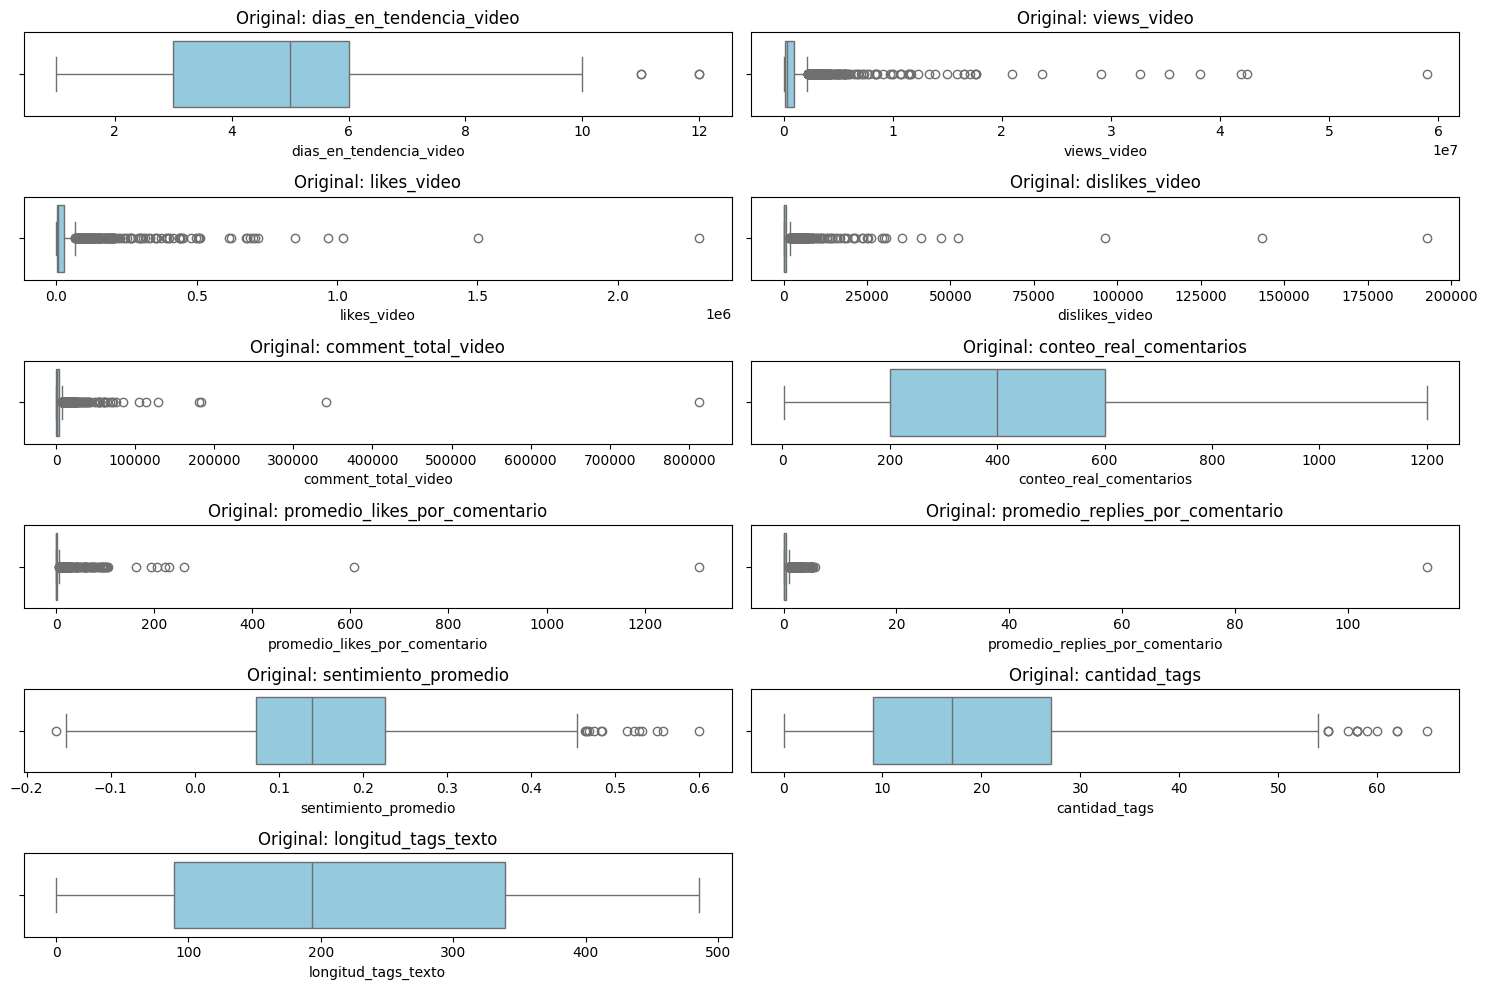

Conteo de Outliers por columna:
dislikes_video                     230
promedio_likes_por_comentario      210
comment_total_video                209
likes_video                        207
promedio_replies_por_comentario    200
views_video                        187
sentimiento_promedio                15
cantidad_tags                       13
dias_en_tendencia_video              4
conteo_real_comentarios              0
longitud_tags_texto                  0
dtype: int64


In [46]:
numeric_cols = ls_cont 
# Convertimos a float para que acepten los límites decimales del IQR
for col in numeric_cols:
    df[col] = df[col].astype('float64')

# Configuración de los cálculos IQR
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

df = df.reset_index(drop=True)

# Visualización ANTES de la limpieza
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(len(numeric_cols) // 2 + 1, 2, i + 1)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Original: {col}')

plt.tight_layout()
plt.show()

# Mostrar el conteo de outliers 
outliers_mask = (df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))
print("Conteo de Outliers por columna:")
print(outliers_mask.sum().sort_values(ascending=False))

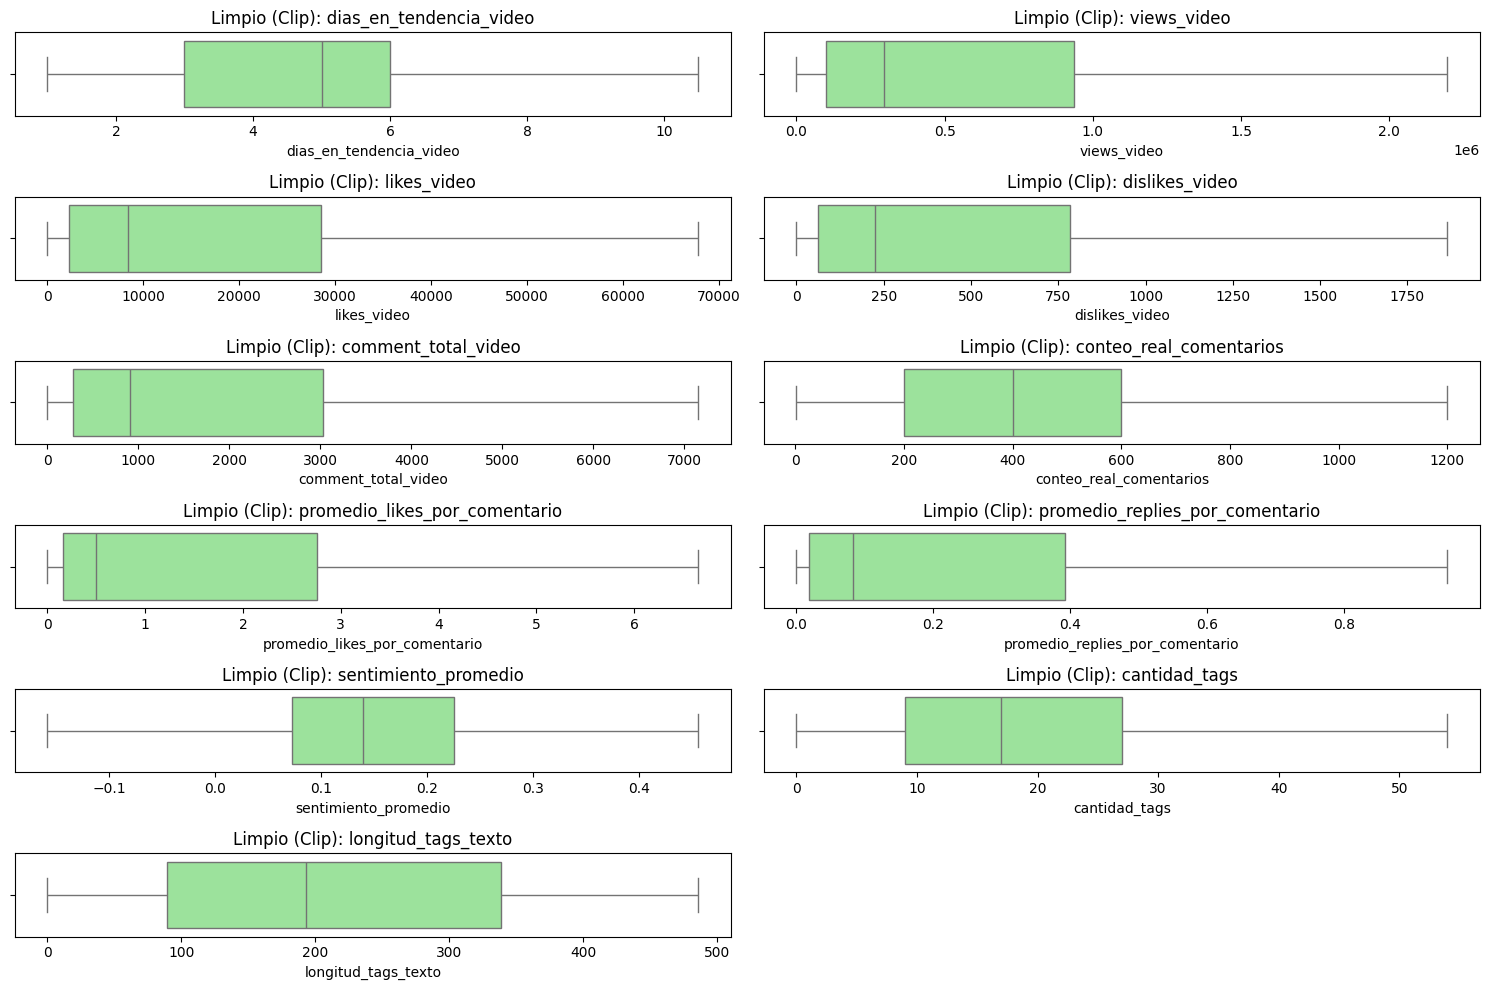

In [47]:
# Hacemos una copia para no alterar el original directamente
df_sin_outliers = df.copy()

#Aplicamos el tratamiento (Clip)
for col in numeric_cols:
    lower = Q1[col] - 1.5 * IQR[col]
    upper = Q3[col] + 1.5 * IQR[col]
    df_sin_outliers[col] = df_sin_outliers[col].clip(lower, upper)

#Visualización DESPUÉS de la limpieza
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(len(numeric_cols) // 2 + 1, 2, i + 1)
    sns.boxplot(x=df_sin_outliers[col], color='lightgreen')
    plt.title(f'Limpio (Clip): {col}')

plt.tight_layout()
plt.show()

### DETECCIÓN Y REMOCIÓN DE VARIABLE POCO POBLADAS

In [48]:
missing_ratio = df_sin_outliers.isnull().mean()
missing_ratio.sort_values(ascending=False)

conteo_real_comentarios               0.02534562
sentimiento_promedio                  0.02534562
promedio_replies_por_comentario       0.02534562
promedio_likes_por_comentario         0.02534562
dias_en_tendencia_video               0.00000000
comment_total_video                   0.00000000
dislikes_video                        0.00000000
likes_video                           0.00000000
views_video                           0.00000000
category_video_Comedy                 0.00000000
category_video_Education              0.00000000
category_video_Entertainment          0.00000000
category_video_Film & Animation       0.00000000
category_video_Gaming                 0.00000000
category_video_Howto & Style          0.00000000
category_video_Music                  0.00000000
category_video_News & Politics        0.00000000
category_video_People & Blogs         0.00000000
category_video_Pets & Animals         0.00000000
category_video_Science & Technology   0.00000000
category_video_Sport

In [49]:
low_populated_vars = missing_ratio[missing_ratio > 0.30].index.tolist()
low_populated_vars

[]

In [50]:
df.drop(columns=low_populated_vars, inplace=True)

#### DETECCIÓN Y REMOCIÓN DE VARIABLES UNITARIAS (UNARIAS)

In [51]:
list_columns = [
    col for col in df_sin_outliers.columns
    if df_sin_outliers[col].apply(lambda x: isinstance(x, list)).any()
]
unary_vars = [
    col for col in df_sin_outliers.columns
    if col not in list_columns and df_sin_outliers[col].nunique(dropna=True) == 1
]
unary_vars

[]

In [52]:
df_sin_outliers.drop(columns=unary_vars, inplace=True)
df_sin_outliers.head()

,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,conteo_real_comentarios,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio,category_video_Comedy,category_video_Education,category_video_Entertainment,category_video_Film & Animation,category_video_Gaming,category_video_Howto & Style,category_video_Music,category_video_News & Politics,category_video_People & Blogs,category_video_Pets & Animals,category_video_Science & Technology,category_video_Sports,category_video_Travel & Events,category_video_None,fuerza_canal_Small Tier,fuerza_canal_Top Tier,cantidad_tags,tiene_tags,longitud_tags_texto,target_viral
0,3.00000000,1874297.00000000,46933.00000000,653.00000000,7154.75000000,300.00000000,0.20000000,0.01333333,0.03773691,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,33.00000000,1,456.00000000,1
1,6.00000000,47188.00000000,410.00000000,19.00000000,109.00000000,291.00000000,3.87285223,0.95178277,0.17029046,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,23.00000000,1,381.00000000,0
2,2.00000000,197531.00000000,7176.00000000,117.00000000,291.00000000,200.00000000,6.65682408,0.20500000,0.13654245,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,44.00000000,1,445.00000000,0
3,7.00000000,159476.00000000,4995.00000000,31.00000000,368.00000000,700.00000000,1.45714286,0.09285714,0.23986667,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,4.00000000,1,58.00000000,0
4,8.00000000,2146662.00000000,52598.00000000,1381.00000000,7154.75000000,799.00000000,0.11000000,0.00375000,0.20554525,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,15.00000000,1,239.00000000,1


### DETECCIÓN Y TRATAMIENTO DE VALORES AUSENTES

In [53]:
df_sin_outliers.isna().sum()

dias_en_tendencia_video                 0
views_video                             0
likes_video                             0
dislikes_video                          0
comment_total_video                     0
conteo_real_comentarios                44
promedio_likes_por_comentario          44
promedio_replies_por_comentario        44
sentimiento_promedio                   44
category_video_Comedy                   0
category_video_Education                0
category_video_Entertainment            0
category_video_Film & Animation         0
category_video_Gaming                   0
category_video_Howto & Style            0
category_video_Music                    0
category_video_News & Politics          0
category_video_People & Blogs           0
category_video_Pets & Animals           0
category_video_Science & Technology     0
category_video_Sports                   0
category_video_Travel & Events          0
category_video_None                     0
fuerza_canal_Small Tier           

In [54]:
# Columnas numéricas 
num_cols = ls_cont 

# Imputer para numéricas (mediana)
imputer_num = SimpleImputer(strategy='median')

# Aplicar imputación
df_sin_outliers[num_cols] = imputer_num.fit_transform(df_sin_outliers[num_cols])

In [55]:
df_sin_outliers.isna().sum()

dias_en_tendencia_video                0
views_video                            0
likes_video                            0
dislikes_video                         0
comment_total_video                    0
conteo_real_comentarios                0
promedio_likes_por_comentario          0
promedio_replies_por_comentario        0
sentimiento_promedio                   0
category_video_Comedy                  0
category_video_Education               0
category_video_Entertainment           0
category_video_Film & Animation        0
category_video_Gaming                  0
category_video_Howto & Style           0
category_video_Music                   0
category_video_News & Politics         0
category_video_People & Blogs          0
category_video_Pets & Animals          0
category_video_Science & Technology    0
category_video_Sports                  0
category_video_Travel & Events         0
category_video_None                    0
fuerza_canal_Small Tier                0
fuerza_canal_Top

In [56]:
df_final = df_sin_outliers.copy()
df_final.drop(columns=["conteo_real_comentarios"], inplace=True)
df_final.sample(10)

,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio,category_video_Comedy,category_video_Education,category_video_Entertainment,category_video_Film & Animation,category_video_Gaming,category_video_Howto & Style,category_video_Music,category_video_News & Politics,category_video_People & Blogs,category_video_Pets & Animals,category_video_Science & Technology,category_video_Sports,category_video_Travel & Events,category_video_None,fuerza_canal_Small Tier,fuerza_canal_Top Tier,cantidad_tags,tiene_tags,longitud_tags_texto,target_viral
1430,8.00000000,1185507.00000000,41753.00000000,1424.00000000,2441.00000000,6.65682408,0.59625000,0.05786562,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,26.00000000,1,333.00000000,0
428,7.00000000,2195833.62500000,67848.37500000,1864.50000000,7154.75000000,6.65682408,0.95178277,0.19879652,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,54.00000000,1,447.00000000,1
993,5.00000000,2195833.62500000,67848.37500000,1864.50000000,7154.75000000,0.09200000,0.01400000,0.31114278,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1.00000000,1,30.00000000,1
66,7.00000000,2195833.62500000,67848.37500000,1864.50000000,7154.75000000,6.65682408,0.95178277,0.04565914,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,31.00000000,1,436.00000000,1
747,5.00000000,101785.00000000,1782.00000000,219.00000000,0.00000000,0.50000000,0.08333333,0.13984750,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,4.00000000,1,46.00000000,0
1440,4.00000000,71779.00000000,3867.00000000,81.00000000,293.00000000,0.36750000,0.00000000,0.41838448,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,9.00000000,1,132.00000000,0
1604,4.00000000,438240.00000000,6419.00000000,597.00000000,499.00000000,1.31500000,0.01750000,0.08879527,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,7.00000000,1,78.00000000,0
762,2.00000000,542629.00000000,67848.37500000,103.00000000,7154.75000000,0.75500000,0.02000000,0.28896347,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,11.00000000,1,99.00000000,0
540,6.00000000,1500132.00000000,26233.00000000,871.00000000,2554.00000000,0.27333333,0.03666667,0.06469995,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,37.00000000,1,344.00000000,0
286,6.00000000,330397.00000000,221.00000000,252.00000000,191.00000000,4.00677966,0.34915254,-0.05553796,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,36.00000000,1,455.00000000,0


In [57]:
df_final.describe()

,dias_en_tendencia_video,views_video,likes_video,dislikes_video,comment_total_video,promedio_likes_por_comentario,promedio_replies_por_comentario,sentimiento_promedio,category_video_Comedy,category_video_Education,category_video_Entertainment,category_video_Film & Animation,category_video_Gaming,category_video_Howto & Style,category_video_Music,category_video_News & Politics,category_video_People & Blogs,category_video_Pets & Animals,category_video_Science & Technology,category_video_Sports,category_video_Travel & Events,category_video_None,fuerza_canal_Small Tier,fuerza_canal_Top Tier,cantidad_tags,tiene_tags,longitud_tags_texto,target_viral
count,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000,1736.00000000
mean,4.60195853,636345.29025058,19307.53665035,534.69412442,2068.77577765,1.75695570,0.24945521,0.15182883,0.07142857,0.02649770,0.18375576,0.04377880,0.03744240,0.14516129,0.16129032,0.03917051,0.14112903,0.01094470,0.02937788,0.09447005,0.00576037,0.00230415,0.39919355,0.05645161,18.32488479,0.95046083,213.88594470,0.15034562
std,2.29909810,723015.48654140,23178.76649516,639.88222398,2418.60822934,2.29061628,0.32503457,0.10864197,0.25761358,0.16065627,0.38739648,0.20466154,0.18989796,0.35236488,0.36790450,0.19405636,0.34825492,0.10407283,0.16891198,0.29256583,0.07569999,0.04796002,0.48987375,0.23085824,12.04599172,0.21705340,142.21293329,0.35751286
min,1.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,-0.15799898,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000
25%,3.00000000,99108.00000000,2239.00000000,62.00000000,276.00000000,0.16000000,0.02000000,0.07366202,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,9.00000000,1.00000000,89.00000000,0.00000000
50%,5.00000000,295596.50000000,8432.00000000,226.00000000,906.00000000,0.50000000,0.08333333,0.13984750,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,17.00000000,1.00000000,193.00000000,0.00000000
75%,6.00000000,937798.25000000,28482.75000000,783.00000000,3027.50000000,2.63533006,0.37500000,0.22285759,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,0.00000000,1.00000000,0.00000000,27.00000000,1.00000000,339.00000000,0.00000000
max,10.50000000,2195833.62500000,67848.37500000,1864.50000000,7154.75000000,6.65682408,0.95178277,0.45575190,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,1.00000000,54.00000000,1.00000000,486.00000000,1.00000000


## Targets

Aqui podriamos agregar graficos para validar el por que de los targets

### Target continuo views_video

In [58]:
y_continuo= df_final.views_video
y_continuo.sample(10)

426      15940.00000000
1697    260966.00000000
1413    788822.00000000
1240   2195833.62500000
930    1523625.00000000
463    2195833.62500000
1635     35707.00000000
1018   1781035.00000000
1213     51194.00000000
1379    683097.00000000
Name: views_video, dtype: float64

In [59]:
ls_cont.remove("conteo_real_comentarios")
ls_cont.remove("views_video")

### Target discreto target_viral 

In [60]:
y_discreto=df_final.target_viral
y_discreto.sample(5)

1253    0
861     0
1553    0
0       1
101     1
Name: target_viral, dtype: int64

## Modelado

### Segmentación de sets

In [61]:
X_continuo = df_final.copy()
X_continuo.drop(columns=['views_video', 'target_viral'])
y_continuo

0      1874297.00000000
1        47188.00000000
2       197531.00000000
3       159476.00000000
4      2146662.00000000
             ...       
1731   1880716.00000000
1732   1572237.00000000
1733    211116.00000000
1734    708934.00000000
1735    129971.00000000
Name: views_video, Length: 1736, dtype: float64

In [62]:
X_discreto = df_final.copy()
X_discreto.drop(columns=['target_viral', 'views_video'])
y_discreto

0       1
1       0
2       0
3       0
4       1
       ..
1731    1
1732    0
1733    0
1734    0
1735    0
Name: target_viral, Length: 1736, dtype: int64

## Entrenamiento Target continuo

In [63]:
X_train, X_test, y_train, y_test = train_test_split(X_continuo, y_continuo, test_size=0.3)

In [64]:
ls_bin.remove("target_viral")
ls_cont,ls_bin

(['dias_en_tendencia_video',
  'likes_video',
  'dislikes_video',
  'comment_total_video',
  'promedio_likes_por_comentario',
  'promedio_replies_por_comentario',
  'sentimiento_promedio',
  'cantidad_tags',
  'longitud_tags_texto'],
 ['category_video_Comedy',
  'category_video_Education',
  'category_video_Entertainment',
  'category_video_Film & Animation',
  'category_video_Gaming',
  'category_video_Howto & Style',
  'category_video_Music',
  'category_video_News & Politics',
  'category_video_People & Blogs',
  'category_video_Pets & Animals',
  'category_video_Science & Technology',
  'category_video_Sports',
  'category_video_Travel & Events',
  'category_video_None',
  'fuerza_canal_Small Tier',
  'fuerza_canal_Top Tier',
  'tiene_tags'])

In [65]:
def auditoria_modelos_completa(X_train, X_test, y_train, y_test, ls_cont, ls_bin):
    """
    Realiza GridSearch, imprime tabla comparativa y genera diagnósticos visuales.
    """
    escaladores = {
        'Standard': StandardScaler(),
        'Robust': RobustScaler(),
        'MinMax': MinMaxScaler()
    }

    # Definimos modelos con sus mallas de hiperparámetros (GridSearch)
    # Si un modelo no necesita parámetros, dejamos la lista vacía []
    configs = {
        'Ridge': {'model': Ridge(), 'params': {'regresor__alpha': [0.1, 1.0, 10.0]}},
        'Lasso': {'model': Lasso(), 'params': {'regresor__alpha': [0.01, 0.1, 1.0]}},
        'Bayesiana': {'model': BayesianRidge(), 'params': {}},
        'ElasticNet': {'model': ElasticNet(), 'params': {'regresor__alpha': [0.1, 1.0], 'regresor__l1_ratio': [0.5]}},
        'Lineal': {'model': LinearRegression(), 'params': {}}
    }

    resultados_cv = []
    modelos_entrenados = {}

    print("=== INICIANDO AUDITORÍA CON GRID SEARCH ===")
    
    for esc_nombre, esc in escaladores.items():
        prepro = ColumnTransformer(transformers=[
            ('num', esc, ls_cont),
            ('bin', 'passthrough', ls_bin)
        ])
        
        for mod_nombre, cfg in configs.items():
            pipeline_base = Pipeline([('prepro', prepro), ('regresor', cfg['model'])])
            
            # Ejecutar GridSearchCV
            search = GridSearchCV(pipeline_base, cfg['params'], cv=4, scoring='r2', n_jobs=-1)
            search.fit(X_train, y_train)
            
            # Guardar mejor modelo para visualización
            mejor_modelo = search.best_estimator_
            modelos_entrenados[f"{mod_nombre} ({esc_nombre})"] = mejor_modelo
            
            # Métricas en Test
            y_pred = mejor_modelo.predict(X_test)
            r2_t = r2_score(y_test, y_pred)
            mae_t = mean_absolute_error(y_test, y_pred)
            
            resultados_cv.append({
                'Configuración': f"{mod_nombre} ({esc_nombre})",
                'Mejor_Param': search.best_params_,
                'CV R2 Promedio': search.best_score_,
                'R2 Test': r2_t,
                'MAE Test': mae_t
                
            })

    # 1. IMPRESIÓN DE TABLA (Tu requerimiento principal)
    df_res = pd.DataFrame(resultados_cv).sort_values(by='CV R2 Promedio', ascending=False)
    print("\n RANKING DE MODELOS:")
    display(df_res)

    # 2. DIAGNÓSTICO DEL GANADOR (Predicción vs Real)
    mejor_config = df_res.iloc[0]['Configuración']
    ganador = modelos_entrenados[mejor_config]
    y_pred_g = ganador.predict(X_test)
    
    plt.figure(figsize=(10, 5))
    plt.scatter(y_test, y_pred_g, alpha=0.5, color='teal', edgecolors='k')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.title(f'Diagnóstico Ganador: {mejor_config}\nReal vs Predicho')
    plt.xlabel('Real')
    plt.ylabel('Predicho')
    plt.grid(True, alpha=0.3)
    plt.show()

    # 3. GRID DE COEFICIENTES (Feature Importance)
    _graficar_grid_importancia(modelos_entrenados, ls_cont + ls_bin)

    return ganador, df_res

def _graficar_grid_importancia(modelos_dict, nombres_features):
    n_modelos = len(modelos_dict)
    cols = 3
    rows = math.ceil(n_modelos / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows), constrained_layout=True)
    axes = axes.flatten()
    
    for i, (nombre, pipe) in enumerate(modelos_dict.items()):
        ax = axes[i]
        modelo_core = pipe.named_steps['regresor']
        
        if hasattr(modelo_core, 'coef_'):
            coefs = modelo_core.coef_
            df_w = pd.DataFrame({'Feature': nombres_features, 'Weight': coefs})
            df_w['Abs'] = df_w['Weight'].abs()
            df_top = df_w.sort_values(by='Abs', ascending=False).head(10)
            
            colors = ['#2ca02c' if x > 0 else '#d62728' for x in df_top['Weight']]
            sns.barplot(data=df_top, x='Weight', y='Feature', ax=ax, palette=colors)
            ax.set_title(nombre)
        else:
            ax.text(0.5, 0.5, "Sin Coeficientes", ha='center')
        
    for j in range(i + 1, len(axes)): axes[j].axis('off')
    plt.suptitle("Impacto de Variables por Modelo", fontsize=20)
    plt.show()

=== INICIANDO AUDITORÍA CON GRID SEARCH ===


/home/jimmii/Documentos/DiplomadoCienciaDeDatos2025-2026/RepoJime/-Titulacion-DiplomadoCienciaDeDatos/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.463e+11, tolerance: 4.559e+10
  model = cd_fast.enet_coordinate_descent(
/home/jimmii/Documentos/DiplomadoCienciaDeDatos2025-2026/RepoJime/-Titulacion-DiplomadoCienciaDeDatos/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.763e+11, tolerance: 4.580e+10
  model = cd_fast.enet_coordinate_descent(
/home/jimmii/Documentos/DiplomadoCienciaDeDatos2025-2026/RepoJime/-Titulacion-DiplomadoCienciaDeDatos/.venv/


 RANKING DE MODELOS:


/home/jimmii/Documentos/DiplomadoCienciaDeDatos2025-2026/RepoJime/-Titulacion-DiplomadoCienciaDeDatos/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.463e+11, tolerance: 4.559e+10
  model = cd_fast.enet_coordinate_descent(
/home/jimmii/Documentos/DiplomadoCienciaDeDatos2025-2026/RepoJime/-Titulacion-DiplomadoCienciaDeDatos/.venv/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.763e+11, tolerance: 4.580e+10
  model = cd_fast.enet_coordinate_descent(
/home/jimmii/Documentos/DiplomadoCienciaDeDatos2025-2026/RepoJime/-Titulacion-DiplomadoCienciaDeDatos/.venv/

,Configuración,Mejor_Param,CV R2 Promedio,R2 Test,MAE Test
5,Ridge (Robust),{'regresor__alpha': 10.0},0.81540601,0.81542251,201442.25724124
0,Ridge (Standard),{'regresor__alpha': 10.0},0.81530251,0.81554777,201411.72878563
2,Bayesiana (Standard),{},0.81500323,0.81566247,201511.06629480
7,Bayesiana (Robust),{},0.81497036,0.81562840,201576.81207355
3,ElasticNet (Standard),"{'regresor__alpha': 0.1, 'regresor__l1_ratio':...",0.81486571,0.81223057,203915.17860584
8,ElasticNet (Robust),"{'regresor__alpha': 0.1, 'regresor__l1_ratio':...",0.81457037,0.81131195,204815.09508185
10,Ridge (MinMax),{'regresor__alpha': 1.0},0.81437963,0.81553998,202139.73771065
11,Lasso (MinMax),{'regresor__alpha': 1.0},0.81390220,0.81527978,202464.48530275
6,Lasso (Robust),{'regresor__alpha': 1.0},0.81390126,0.81528015,202464.91980713
1,Lasso (Standard),{'regresor__alpha': 1.0},0.81390114,0.81528024,202465.03219335


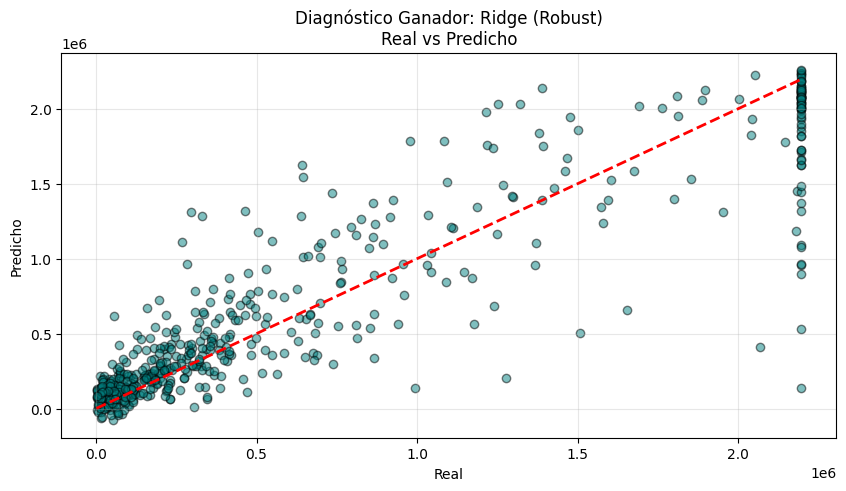

/tmp/ipykernel_55187/4201732064.py:100: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_55187/4201732064.py:100: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_55187/4201732064.py:100: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_55187/4201732064.py:100: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_55187/4201732064.py:100: FutureWarning:



Passing `palette` without assigning `hue` 

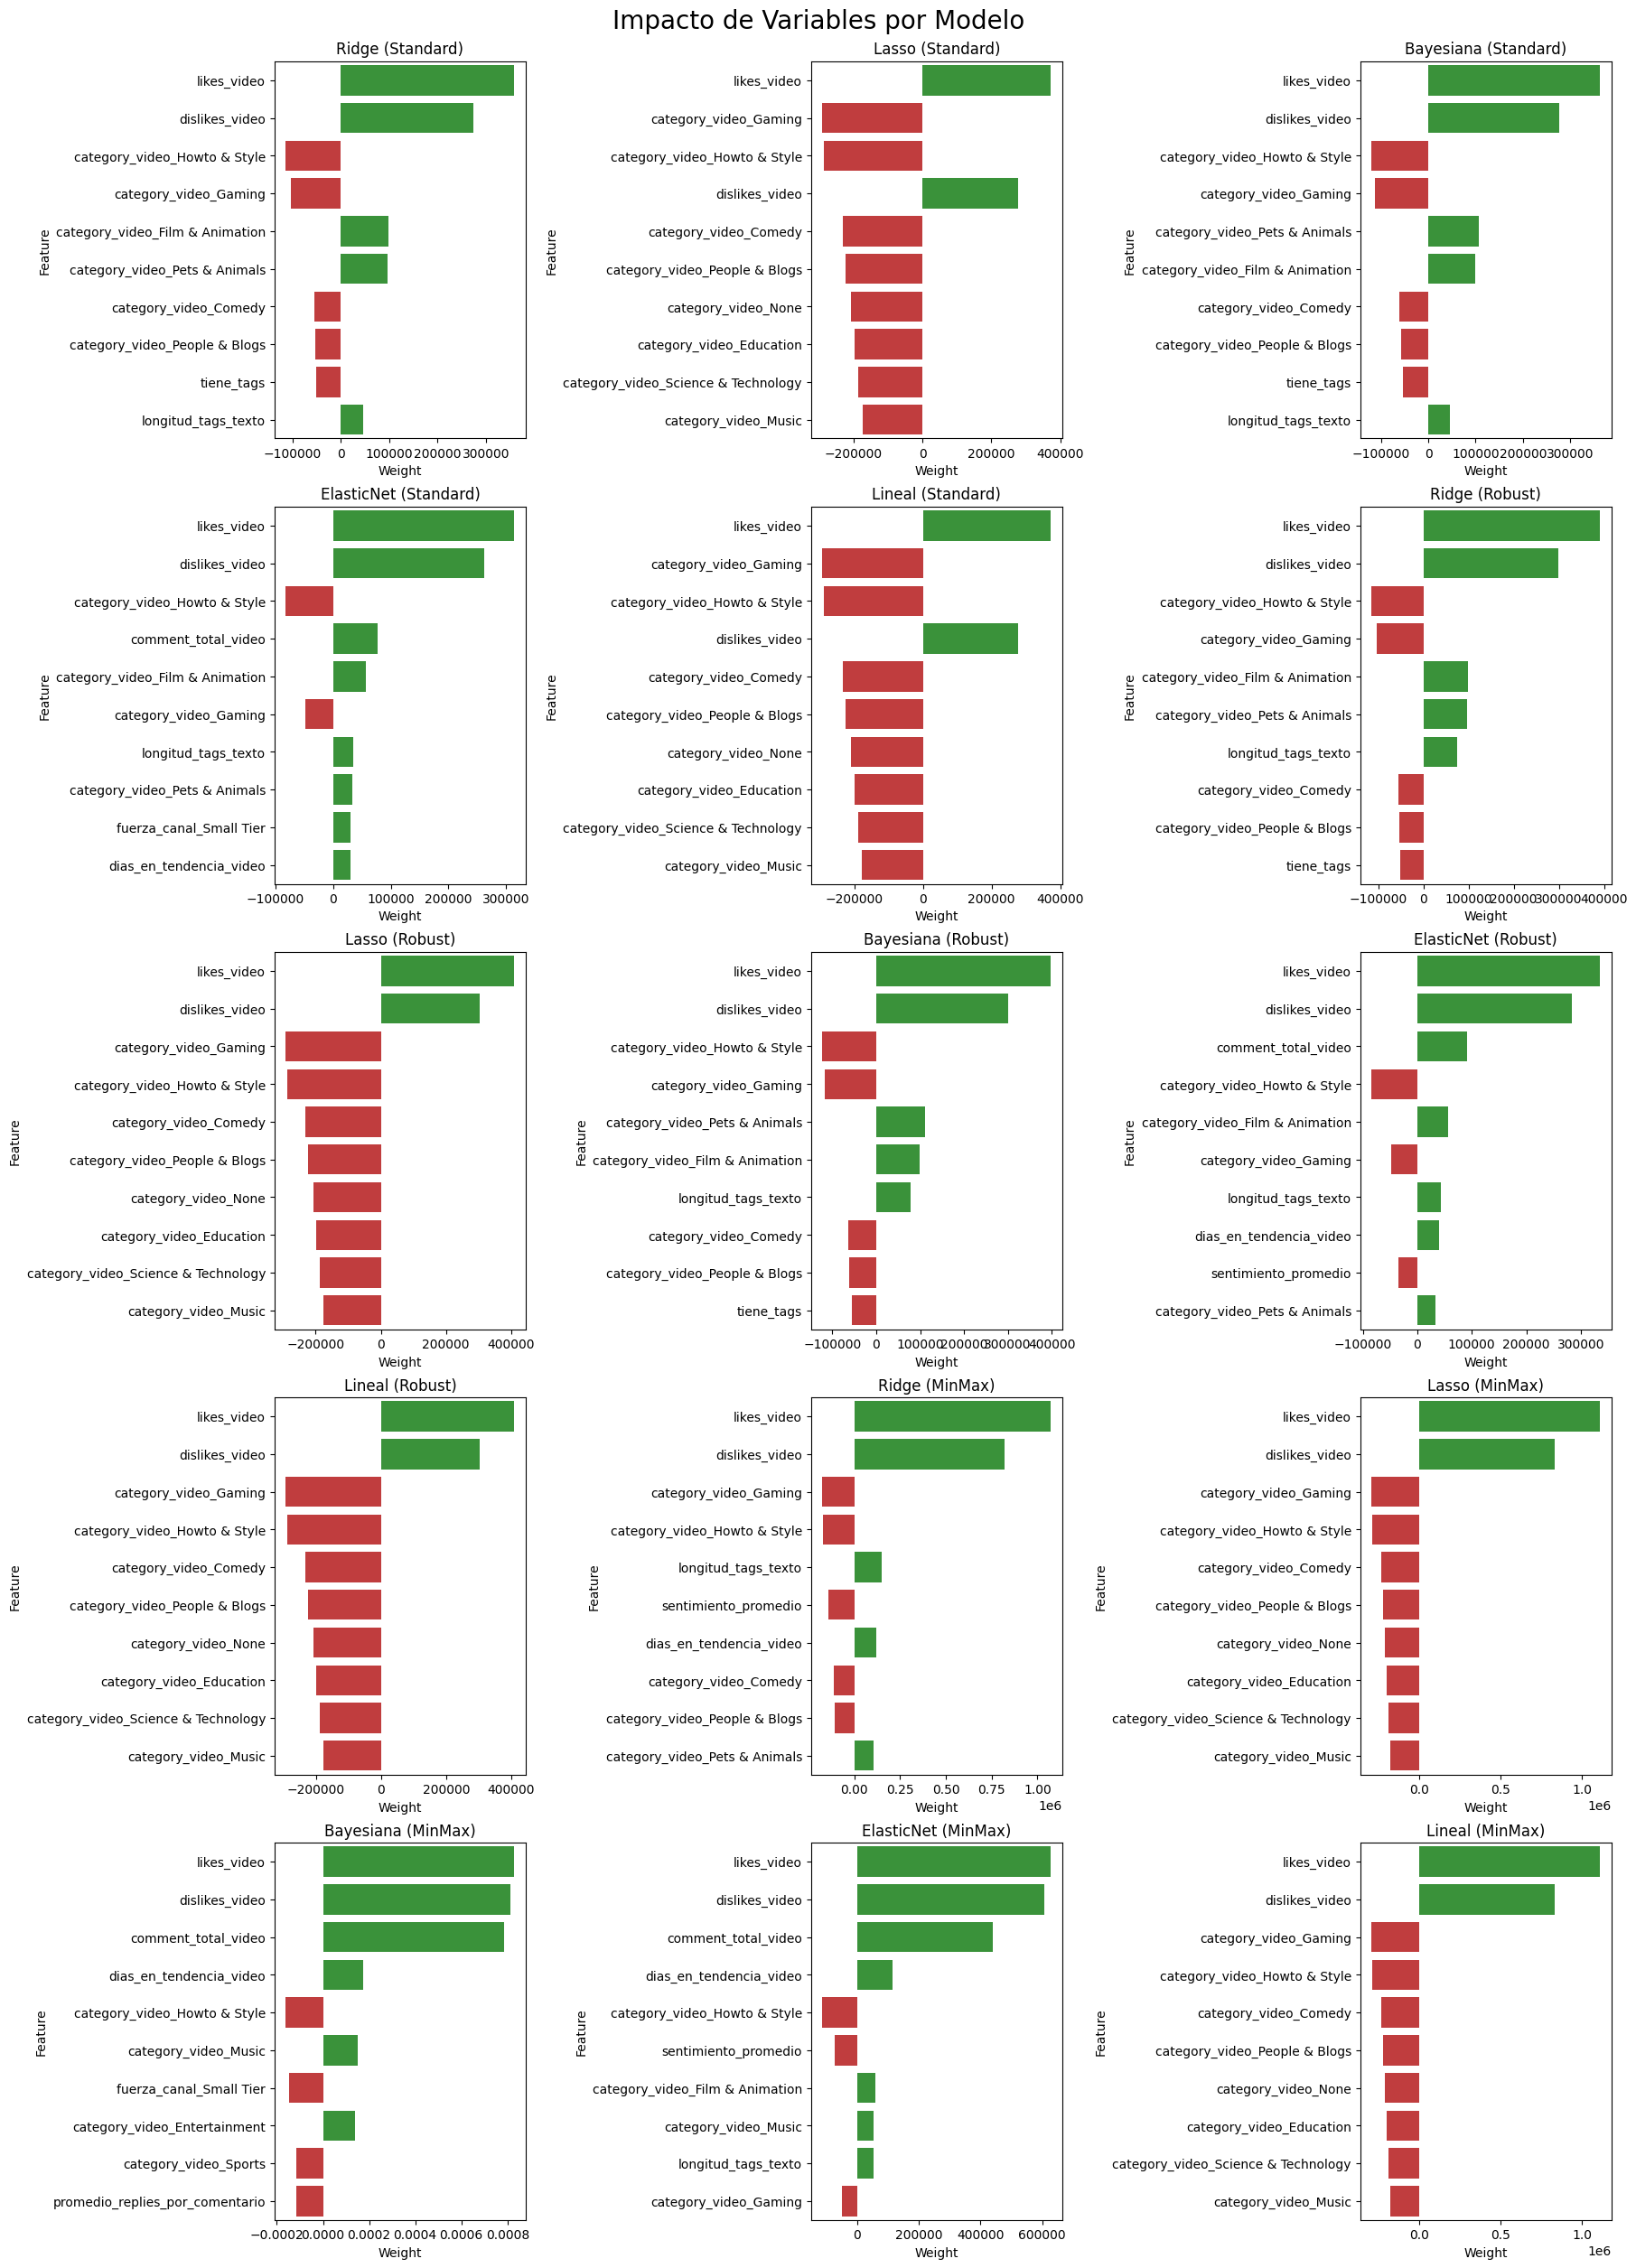

(Pipeline(steps=[('prepro',
                  ColumnTransformer(transformers=[('num', RobustScaler(),
                                                   ['dias_en_tendencia_video',
                                                    'likes_video',
                                                    'dislikes_video',
                                                    'comment_total_video',
                                                    'promedio_likes_por_comentario',
                                                    'promedio_replies_por_comentario',
                                                    'sentimiento_promedio',
                                                    'cantidad_tags',
                                                    'longitud_tags_texto']),
                                                  ('bin', 'passthrough',
                                                   ['category_video_Comedy',
                                                    'category_v

In [66]:
auditoria_modelos_completa(X_train, X_test, y_train, y_test, ls_cont, ls_bin)

## Entrenamiento Target discreto

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X_discreto, y_discreto, test_size=0.3)

In [68]:
def auditoria_clasificacion(X_train, X_test, y_train, y_test, ls_cont, ls_bin):
    """
    Torneo de modelos de clasificación, visualización de métricas
    y desglose de coeficientes para interpretación de negocio.
    """
    escaladores = {
        'Standard': StandardScaler(),
        'Robust': RobustScaler(),
        'MinMax': MinMaxScaler()
    }

    param_grid = {
        'clf__C': [0.1, 1, 10],
        'clf__solver': ['lbfgs', 'liblinear']
    }

    resultados_cv = []
    modelos_entrenados = {}
    mejor_auc_global = -1
    ganador_absoluto = None
    config_ganadora = ""

    print("=== INICIANDO AUDITORÍA DE CLASIFICACIÓN (VIRALIDAD) ===")
    
    for esc_nombre, esc in escaladores.items():
        prepro = ColumnTransformer(transformers=[
            ('num', esc, ls_cont),
            ('bin', 'passthrough', ls_bin)
        ])
        
        pipe = Pipeline([('prepro', prepro), ('clf', LogisticRegression(max_iter=5000))])
        
        grid = GridSearchCV(pipe, param_grid, cv=4, scoring='roc_auc', n_jobs=-1)
        grid.fit(X_train, y_train)
        
        nombre_config = f"Logística ({esc_nombre})"
        mejor_mod_esc = grid.best_estimator_
        modelos_entrenados[nombre_config] = mejor_mod_esc
        
        y_prob = mejor_mod_esc.predict_proba(X_test)[:, 1]
        auc_t = roc_auc_score(y_test, y_prob)
        
        resultados_cv.append({
            'Configuración': nombre_config,
            'Mejor_C': grid.best_params_['clf__C'],
            'ROC_AUC_Test': auc_t,
            'Accuracy_Test': accuracy_score(y_test, mejor_mod_esc.predict(X_test)),
            'F1_Test': f1_score(y_test, mejor_mod_esc.predict(X_test))
        })

        if auc_t > mejor_auc_global:
            mejor_auc_global = auc_t
            ganador_absoluto = mejor_mod_esc
            config_ganadora = nombre_config

    # 1. Ranking de Resultados
    df_ranking = pd.DataFrame(resultados_cv).sort_values(by='ROC_AUC_Test', ascending=False)
    print("\nRANKING DE MODELOS DE CLASIFICACIÓN:")
    display(df_ranking)

    # 2. Extracción de Coeficientes (Tu bloque de código integrado)
    nombres_variables = ls_cont + ls_bin
    coefs = ganador_absoluto.named_steps['clf'].coef_[0]

    if len(nombres_variables) == len(coefs):
        df_ecuacion = pd.DataFrame({
            'Variable': nombres_variables,
            'Peso (Coeficiente)': coefs,
            'Impacto Absoluto': np.abs(coefs)
        })
        
        df_ecuacion = df_ecuacion.sort_values(by='Impacto Absoluto', ascending=False).reset_index(drop=True)
        
        print(f"\nTABLA DE COEFICIENTES - GANADOR: {config_ganadora}")
        print("(Top 15 más influyentes en la Viralidad)")
        display(df_ecuacion.head(15))
        
        print("\nInterpretación:")
        print("- Peso Positivo: Aumenta la probabilidad de ser Viral.")
        print("- Peso Negativo: Disminuye la probabilidad de ser Viral.")
        print("- Magnitud: Qué tan fuerte es el efecto de esa variable.")

    # 3. Evaluación Visual del Ganador
    y_pred_g = ganador_absoluto.predict(X_test)
    y_prob_g = ganador_absoluto.predict_proba(X_test)[:, 1]

    plt.figure(figsize=(12, 5))
    # Matriz de Confusión
    plt.subplot(1, 2, 1)
    sns.heatmap(confusion_matrix(y_test, y_pred_g), annot=True, fmt='d', cmap='Blues')
    plt.title('Matriz de Confusión (Ganador)')
    
    # Curva ROC
    plt.subplot(1, 2, 2)
    fpr, tpr, _ = roc_curve(y_test, y_prob_g)
    plt.plot(fpr, tpr, label=f'AUC = {mejor_auc_global:.3f}')
    plt.plot([0, 1], [0, 1], 'r--')
    plt.title('Curva ROC (Ganador)')
    plt.legend()
    plt.show()

    return ganador_absoluto, df_ranking

=== INICIANDO AUDITORÍA DE CLASIFICACIÓN (VIRALIDAD) ===

RANKING DE MODELOS DE CLASIFICACIÓN:


,Configuración,Mejor_C,ROC_AUC_Test,Accuracy_Test,F1_Test
0,Logística (Standard),0.10000000,0.95967108,0.93666027,0.76923077
1,Logística (Robust),0.10000000,0.95930830,0.93666027,0.76923077
2,Logística (MinMax),0.10000000,0.95558982,0.93857965,0.77142857



TABLA DE COEFICIENTES - GANADOR: Logística (Standard)
(Top 15 más influyentes en la Viralidad)


,Variable,Peso (Coeficiente),Impacto Absoluto
0,dislikes_video,1.14169595,1.14169595
1,likes_video,1.01516071,1.01516071
2,comment_total_video,0.44653747,0.44653747
3,category_video_Howto & Style,-0.44545763,0.44545763
4,promedio_likes_por_comentario,-0.26170325,0.26170325
5,category_video_Pets & Animals,0.18259990,0.18259990
6,category_video_Film & Animation,0.15931293,0.15931293
7,longitud_tags_texto,0.15208679,0.15208679
8,fuerza_canal_Top Tier,0.13972764,0.13972764
9,category_video_Comedy,-0.10254550,0.10254550



Interpretación:
- Peso Positivo: Aumenta la probabilidad de ser Viral.
- Peso Negativo: Disminuye la probabilidad de ser Viral.
- Magnitud: Qué tan fuerte es el efecto de esa variable.


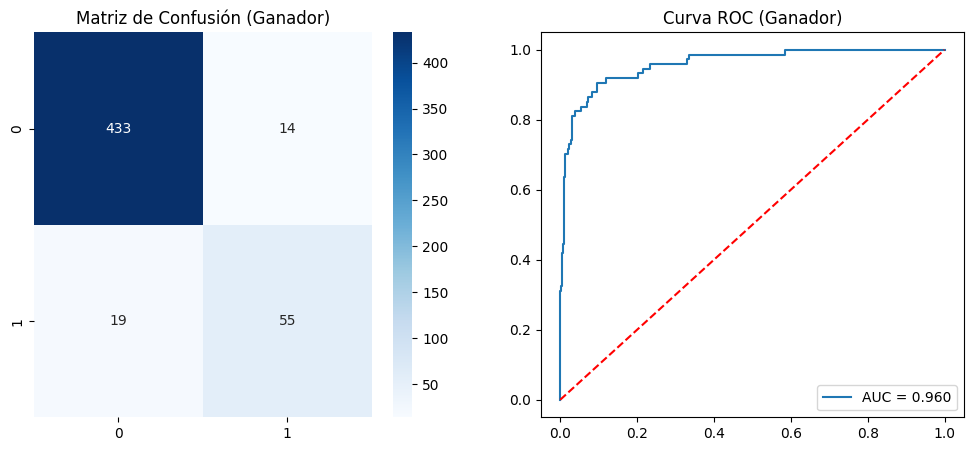

(Pipeline(steps=[('prepro',
                  ColumnTransformer(transformers=[('num', StandardScaler(),
                                                   ['dias_en_tendencia_video',
                                                    'likes_video',
                                                    'dislikes_video',
                                                    'comment_total_video',
                                                    'promedio_likes_por_comentario',
                                                    'promedio_replies_por_comentario',
                                                    'sentimiento_promedio',
                                                    'cantidad_tags',
                                                    'longitud_tags_texto']),
                                                  ('bin', 'passthrough',
                                                   ['category_video_Comedy',
                                                    'category

In [69]:
auditoria_clasificacion(X_train, X_test, y_train, y_test, ls_cont, ls_bin)